Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

Loading Data

In [2]:
# Load + shuffle dataset
df = pd.read_csv("realistic_migraine_data.csv").sample(frac=1, random_state=42)

X = df.drop("Migraine_Score", axis=1)
y = df["Migraine_Score"]

# train / val / test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

Training the XGBoost model:

In [3]:
# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Predictions
pred = xgb_model.predict(X_test)

Evaluation

In [4]:
# Evaluation
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²  :", r2_score(y_test, pred))

MAE : 2.0354256978607177
RMSE: 2.564979290779798
R²  : 0.9787217702580799


Visualization

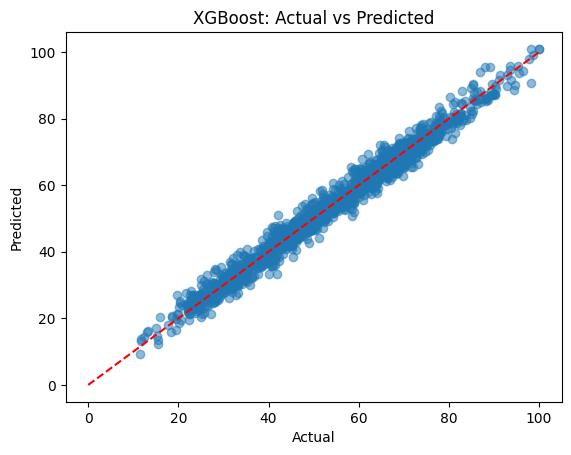

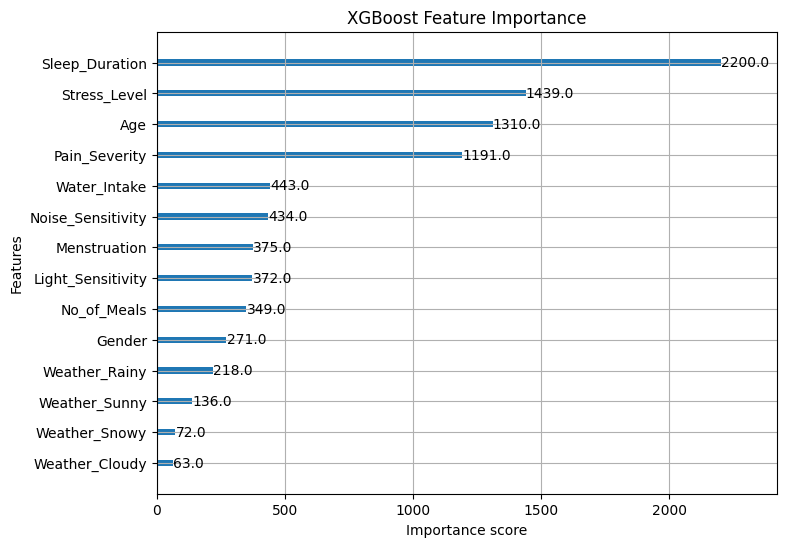

In [5]:
# Visualization: Actual vs Predicted
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([0,100], [0,100], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

# Feature importance
fig, ax = plt.subplots(figsize=(8, 6))
xgb.plot_importance(xgb_model, max_num_features=14, ax=ax)
ax.set_title("XGBoost Feature Importance")
plt.show()